In [1]:
from matplotlib.ticker import LinearLocator
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from utils.integrate import leggauss
from solver.least_square import solve
from modules.solution import MicroMacroConstructor1D
from modules.generator import Sample1D
from geometry.meshxd_ds import UniformMeshX, UniformMeshXV
from constraints.continuous1d import (
    MicroMacroPointwiseInteriorConstraint1D as EQ,
    MicroMacroPointwiseBoundaryConstraint1D as BC,
)
from configuration.rte1d_settings_ex1_aprfm import get_config

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Mp_rho = rte_config.model.Mp["rho"]
Mp_g = rte_config.model.Mp["g"]
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["rho/g"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_rho = UniformMeshX(domain=domain, strides=strides)
mesh_g = UniformMeshXV(domain=domain, strides=strides)
# print(f"Mp_rho: {Mp_rho}, Mp_g: {Mp_g} - Jn_rho: {Jn["rho"]}, Jn_g: {Jn["g"]}")

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_v = jnp.split(jnp.array([0.0, 0.0]), 2, axis=0)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_v)
bc_instance = bc.apply(params, dummy_x, dummy_v)

In [6]:
# (2, Mp_rho*Jn_rho+Mp_g*Jn_g), (Mp_rho*Jn_rho+Mp_g*Jn_g,)
eq_instance.shape, bc_instance.shape

((3, 160), (160,))

In [7]:
def eq_fn(x, v):
    return partial(rte.apply, params)(x, v)


def bc_fn(x, v):
    return partial(bc.apply, params)(x, v)


def rhs_fn(x, v):
    quadratures = leggauss(num_quads)
    q = source_fn(x, v).squeeze()
    avg_q = integrator(source_fn, quadratures, 1)(x)
    return jnp.array([avg_q, (q - avg_q), 0])
    # return jnp.array([avg_q, kn * (q - avg_q), 0])
    # return jnp.array([avg_q, kn * (q - avg_q)])


def integrator(fn, quadratures, argnum):
    pts, ws = quadratures

    def integral_fn(*args):
        args = list(args)
        in_axes_ = [None] * len(args)
        args.insert(argnum, pts)
        in_axes_.insert(argnum, int(0))
        vmap_fns = vmap(fn, in_axes=in_axes_, out_axes=-1)(*args)
        out = jnp.dot(vmap_fns, ws).squeeze()
        return jnp.array(out)

    return integral_fn


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
#     vmap(jit(eq_fn)),
#     vmap(jit(bc_fn)),
#     vmap(jit(rhs_fn)),
# )

# vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = vmap(eq_fn), vmap(bc_fn), vmap(rhs_fn)

# time
# vmap - 9:11
# vmap+jit - 1:55
# jit+vmap - 1:49

In [8]:
sampler = Sample1D(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode
)
xv_int, xv_bcl, xv_bcr = sampler.pts_int, sampler.pts_left, sampler.pts_right

In [9]:
# Evaluate the functions
bc_left, bc_right = vmap_bc_fn(*xv_bcl), vmap_bc_fn(*xv_bcr)

In [10]:
eq_int = vmap_eq_fn(*xv_int)

In [11]:
rhs_int = vmap_rhs_fn(*xv_int)

In [12]:
print(f"Boundary: {bc_left.shape}, {bc_right.shape}, Interior: {eq_int.shape}")

Boundary: (64, 160), (64, 160), Interior: (900, 3, 160)


In [13]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, eq_int.reshape(-1, num_unknowns)], axis=0
)
vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size = bc_left.shape[0]
vector_b[:bdy_size, 0] = bdy_value["f_l"](xv_bcl[-1])
vector_b[bdy_size : 2 * bdy_size, 0] = bdy_value["f_r"](xv_bcr[-1])
vector_b[2 * bdy_size :, 0] = rhs_int.reshape(-1)
print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (2828, 160), Vector b: (2828, 1)


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (160, 1)


In [15]:
np.linalg.norm(matrix_A @ vector_U - vector_b) / np.linalg.norm(vector_b)

5.229198526048958e-13

In [16]:
from numpy.linalg import cond

print(f"Condition number: {cond(matrix_A)}")

Condition number: 1.1788438864899648e+18


In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = MicroMacroConstructor1D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, v):
    return partial(constructor.apply, params)(x, v)

In [20]:
dummy_z = jnp.array([0.7, -0.5])
dummy_x, dummy_v = jnp.split(dummy_z, 2, axis=0)
print(f"f({dummy_z}) = {jit(approx_fn)(dummy_x, dummy_v)}")  # 0.15

f([ 0.7 -0.5]) = 0.2999999999968921


In [21]:
vmap_approx_fn = vmap(approx_fn)

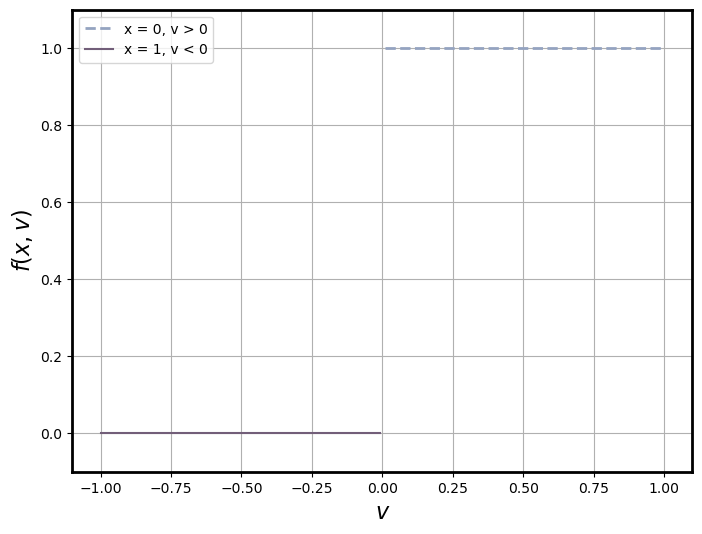

In [22]:
plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.plot(
    xv_bcl[1],
    vmap_approx_fn(*xv_bcl),
    "--",
    color="#94A3C0",
    markersize=10,
    linewidth=2,
    label="x = 0, v > 0",
)
plt.plot(
    xv_bcr[1],
    vmap_approx_fn(*xv_bcr),
    "-",
    color="#725E79",
    label="x = 1, v < 0",
)
plt.ylim(ymin=-0.1, ymax=1.1)
plt.xlabel(r"$v$", fontsize=16)
plt.ylabel(r"$f (x, v)$", fontsize=16)
plt.grid()
plt.legend()
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
# plt.savefig("rte_approx_BC.png", dpi=300)
plt.show()
plt.close()

In [23]:
data = np.load(f"../src/data/rte1d_ex1_ref_{kn:.1e}.npz")
mesh_x, mesh_v, F = data["mesh_x"], data["mesh_v"], data["F"]
X, V = np.meshgrid(mesh_x, mesh_v)
XV = np.stack([X, V], axis=-1)
F_hat = vmap_approx_fn(*np.split(XV.reshape(-1, 2), 2, axis=1)).reshape(
    X.shape
)
# np.savez("../src/data/rte1d_solutions_kn.npz", X=X, V=V, F=F, F_hat=F_hat)

In [24]:
np.savez(
    f"../src/data/aprfm1d_solutions_{kn:.1e}.npz", X=X, V=V, F=F, F_hat=F_hat
)

In [25]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(6.95863614e-12, dtype=float64)

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


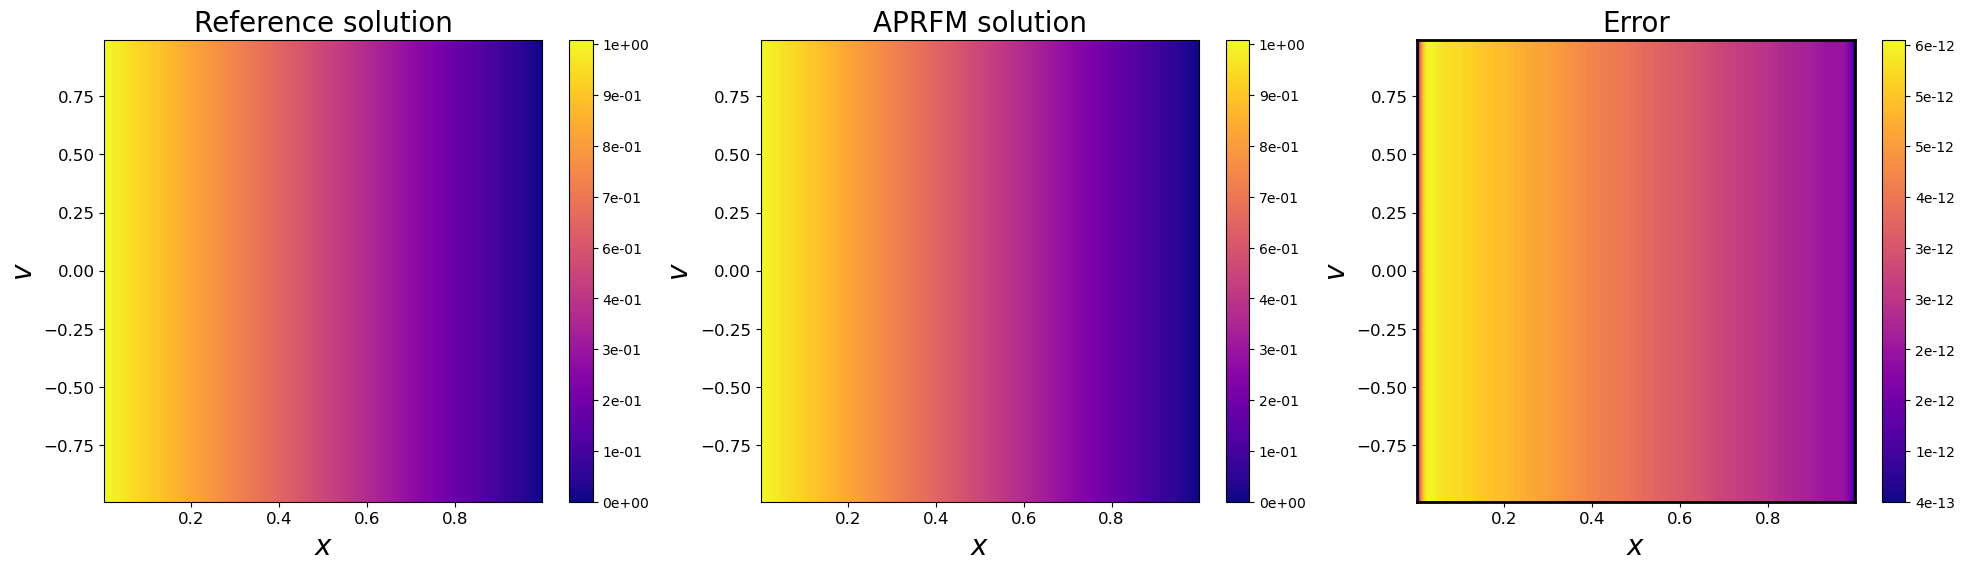

In [26]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, V, F_hat, 100, cmap="plasma")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("APRFM solution", font_format)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="plasma")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# line width of four axises
ax = plt.gca()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)

plt.show()
plt.close()

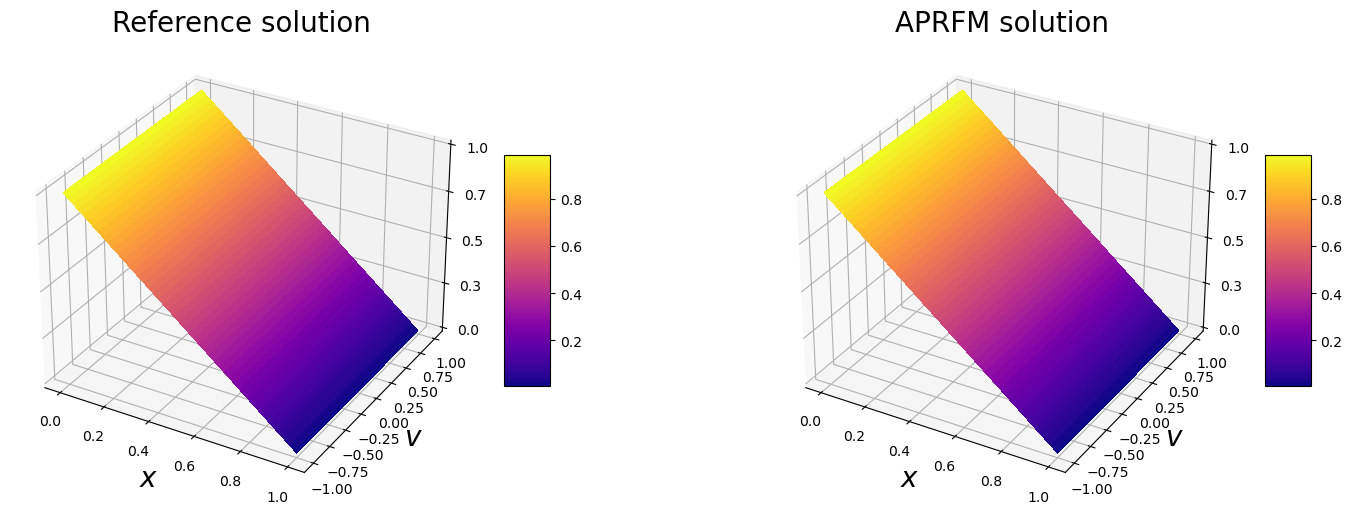

In [27]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(
    X, V, F, cmap="plasma", linewidth=0, antialiased=False
)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(
    X, V, F_hat, cmap="plasma", linewidth=0, antialiased=False
)
ax2.set_xlabel(r"$x$", font_format)
ax2.set_ylabel(r"$v$", font_format)
ax2.set_title("APRFM solution", font_format)
ax2.zaxis.set_major_locator(LinearLocator(5))
ax2.zaxis.set_major_formatter("{x:.01f}")
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)
fig.colorbar(surf2, shrink=0.5, aspect=5)

plt.show()
plt.close()